# Instructor Effectiveness Modeling (EdTech Context)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ritikrajora20072110-ship-it/instructor-effectiveness-modeling/blob/main/instructor_effectiveness_modeling.ipynb)

**Role:** Data Science / AI Content Specialist Intern  
**Submission Format:** Google Colab / Jupyter Notebook  
**Allowed Libraries:** Python, pandas, numpy, scikit-learn, matplotlib / seaborn  
**Strict Constraints:** No LLMs, no external datasets, no AutoML tools.

---

## Executive Summary & Problem Context
An EdTech platform delivers the same curriculum across multiple batches taught by different instructors. In this setup:
* Each instructor teaches multiple batches ($N_i \in [7, 31]$ in our dataset).
* An instructor may teach the same course across multiple batches or across multiple different courses over time.
* The company seeks to evaluate and predict **instructor effectiveness tiers** (Low, Medium, High) to drive coaching, optimize batch allocations, and recognize excellence.

### End-to-End Workflow Architecture
1. **Exploratory Data Analysis (EDA):** Univariate distributions, collinearity mapping, batch-level variances, and course baseline checks.
2. **Defining Instructor Effectiveness:** Formulating a principled, multi-dimensional **Instructor Effectiveness Score (IES)** spanning *Outcomes (40%)*, *Engagement (30%)*, and *Satisfaction (30%)*, with empirical shrinkage for low-batch uncertainty. Discretizing into balanced tiers.
3. **Batch-to-Instructor Level Aggregation:** Computing central tendencies (mean/median), stability/consistency metrics ($\sigma$), and volume indicators.
4. **Machine Learning Modeling:** Benchmarking an interpretable Baseline (Dummy Classifier), Linear Model (Regularized Logistic Regression), and Non-Linear Ensembles (Random Forest & Gradient Boosting) under Stratified 5-Fold Cross-Validation.
5. **Evaluation & Business Trade-offs:** Precision, Recall, Macro F1, Confusion Matrices, and Multiclass ROC-AUC analysis.
6. **Interpretability & Feature Importance:** Gini Impurity reduction and Permutation Importance analysis.
7. **Mandatory Analysis Questions:** In-depth answers to all 5 strategic, technical, and ethical questions.

In [1]:
# 1. Imports and Environmental Setup
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
)
from sklearn.inspection import permutation_importance

# Visualization Settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica', 'Arial', 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

print("[+] Environment initialized successfully.")

[+] Environment initialized successfully.


In [2]:
# 2. Loading the Dataset
DATA_FILE = "instructor_effectiveness_data.csv"
if not os.path.exists(DATA_FILE):
    local_fallback = "/Users/ritikrajora20072110gmailcom/.gemini/antigravity/scratch/edtech_assignment/instructor_effectiveness_data.csv"
    if os.path.exists(local_fallback):
        DATA_FILE = local_fallback
    else:
        import urllib.request
        url = "https://raw.githubusercontent.com/ritikrajora20072110-ship-it/instructor-effectiveness-modeling/main/instructor_effectiveness_data.csv"
        print(f"Downloading dataset for Google Colab session from GitHub...")
        urllib.request.urlretrieve(url, DATA_FILE)
        print("[+] Dataset downloaded successfully.")

df = pd.read_csv(DATA_FILE)
print(f"Dataset Dimensions: {df.shape[0]} rows (batches) x {df.shape[1]} columns")
print(f"Unique Instructors : {df['instructor_id'].nunique()}")
print(f"Unique Courses     : {df['course_id'].nunique()}")
print(f"Unique Batches     : {df['batch_id'].nunique()}")
print(f"Total Missing Values: {df.isnull().sum().sum()}")
df.head()

Dataset Dimensions: 2000 rows (batches) x 12 columns
Unique Instructors : 120
Unique Courses     : 25
Unique Batches     : 2000
Total Missing Values: 0


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


---
## Step 1: Exploratory Data Analysis (EDA)

We explore the distributions, central tendencies, and correlations across the 9 continuous operational metrics:
- **Learner Outcomes:** `completion_rate`, `dropout_rate`, `avg_score_improvement`, `avg_quiz_score`
- **Engagement Metrics:** `avg_watch_time`, `assignment_submission_rate`, `forum_activity_rate`
- **Feedback Metrics:** `avg_feedback_score`, `feedback_response_rate`

In [3]:
# Statistical Summary
stats_df = df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats_df.round(3)

,mean,std,min,25%,50%,75%,max
completion_rate,0.603,0.160,0.300,0.489,0.603,0.713,0.980
avg_score_improvement,27.036,5.717,6.159,23.125,26.939,30.886,40.000
avg_quiz_score,77.956,10.696,40.387,70.898,78.021,85.444,100.000
dropout_rate,0.395,0.163,0.020,0.280,0.395,0.511,0.700
avg_watch_time,0.777,0.145,0.287,0.675,0.780,0.894,1.000
assignment_submission_rate,0.753,0.148,0.251,0.652,0.756,0.856,1.000
forum_activity_rate,0.250,0.101,0.000,0.180,0.250,0.319,0.641
avg_feedback_score,4.207,0.419,2.640,3.919,4.206,4.503,5.000
feedback_response_rate,0.737,0.149,0.260,0.633,0.737,0.846,1.000


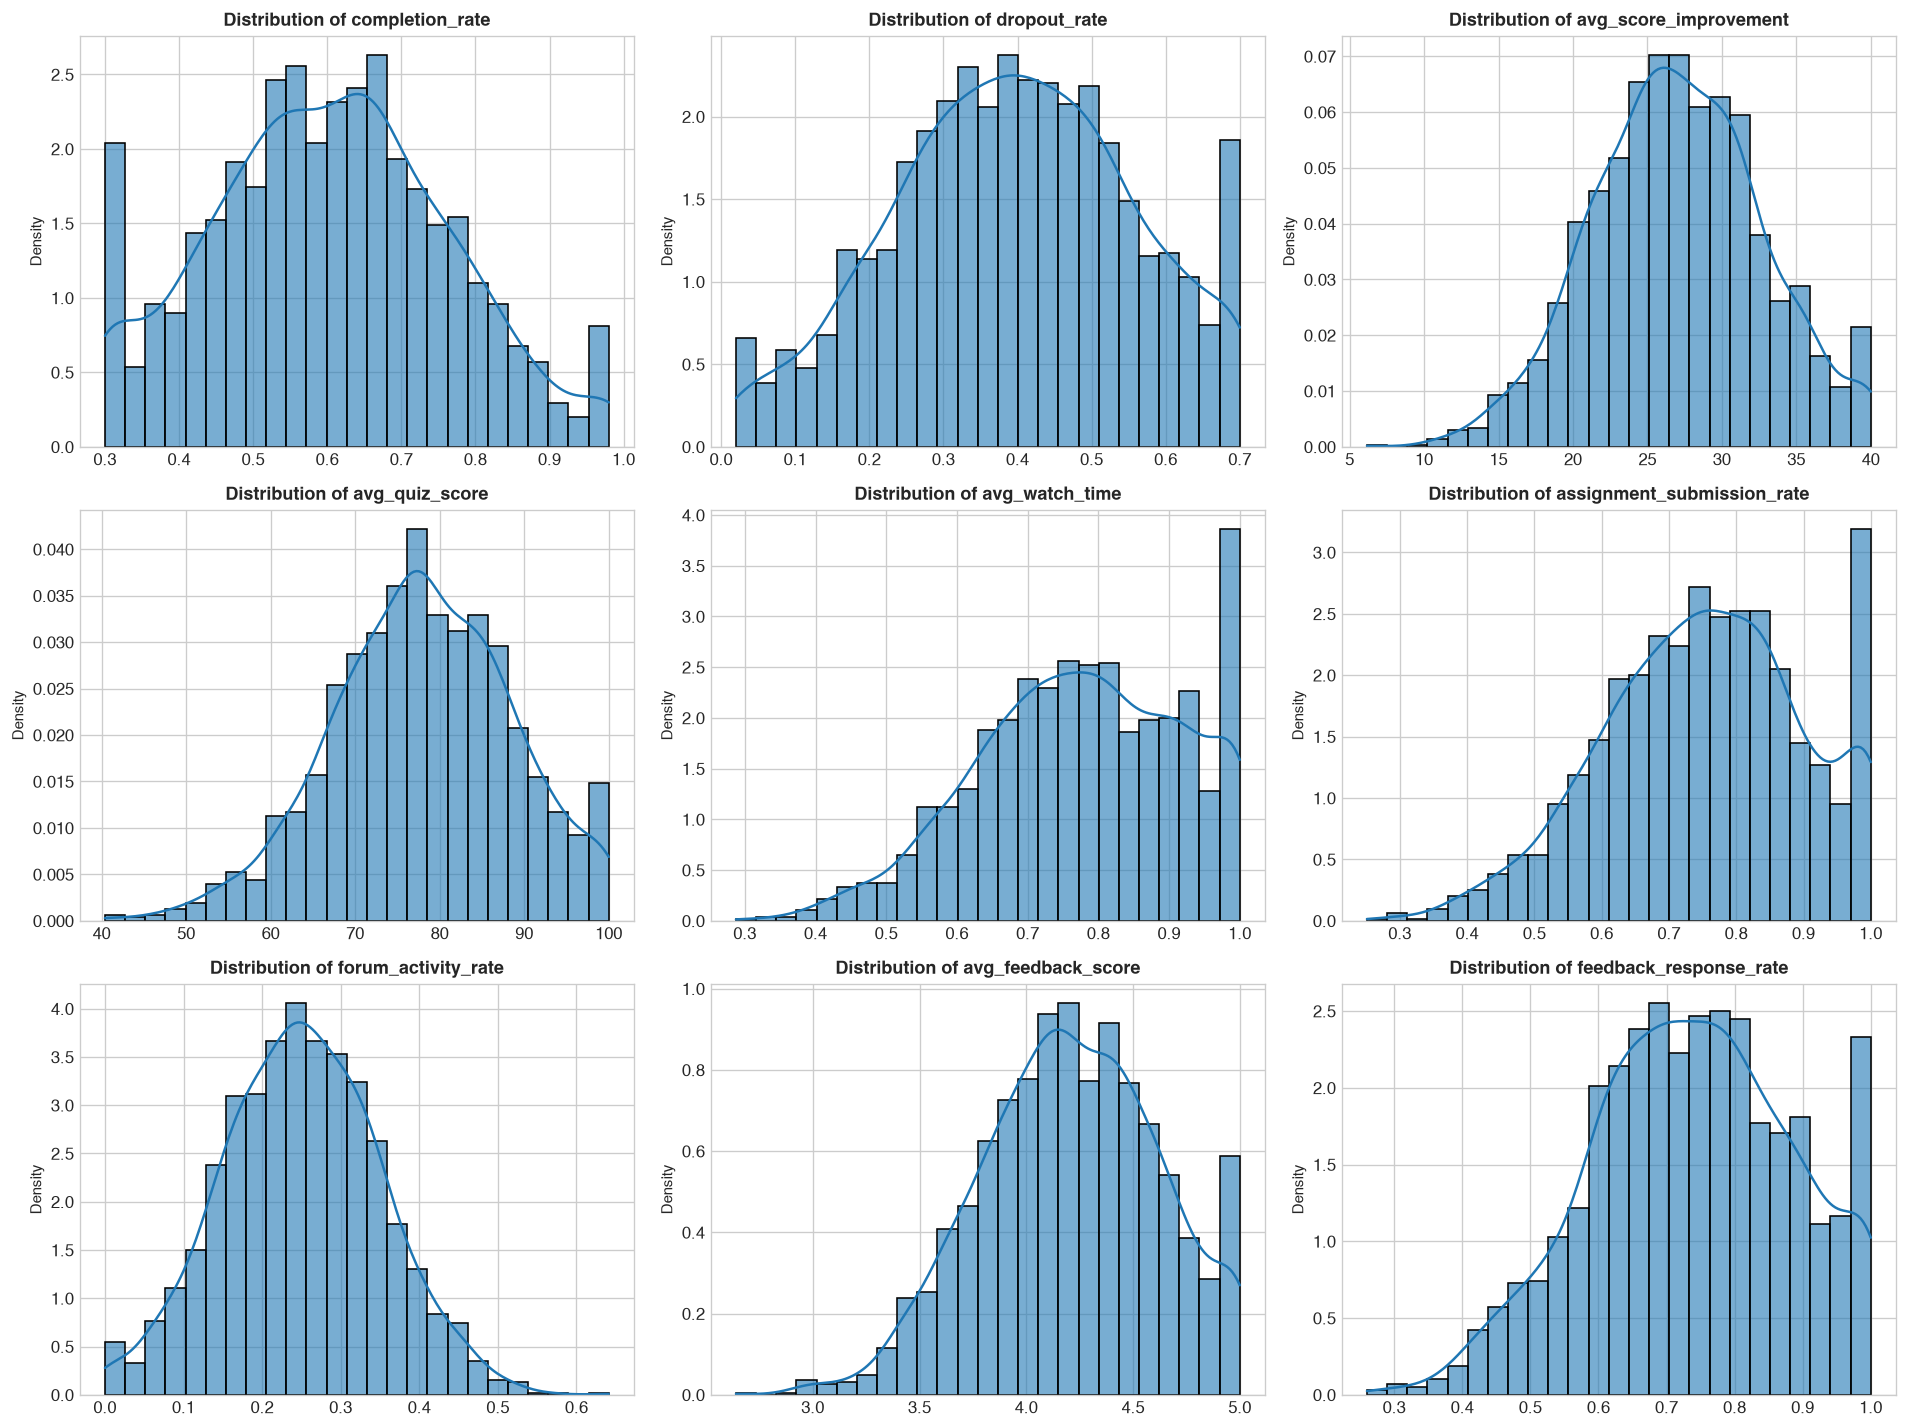

In [4]:
# Visualizing Distributions of Operational Metrics
metric_cols = [
    'completion_rate', 'dropout_rate', 'avg_score_improvement', 'avg_quiz_score',
    'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
    'avg_feedback_score', 'feedback_response_rate'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(metric_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='#1f77b4', bins=25, stat="density", alpha=0.6)
    axes[idx].set_title(f"Distribution of {col}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("Density", fontsize=9)

plt.tight_layout()
plt.show()

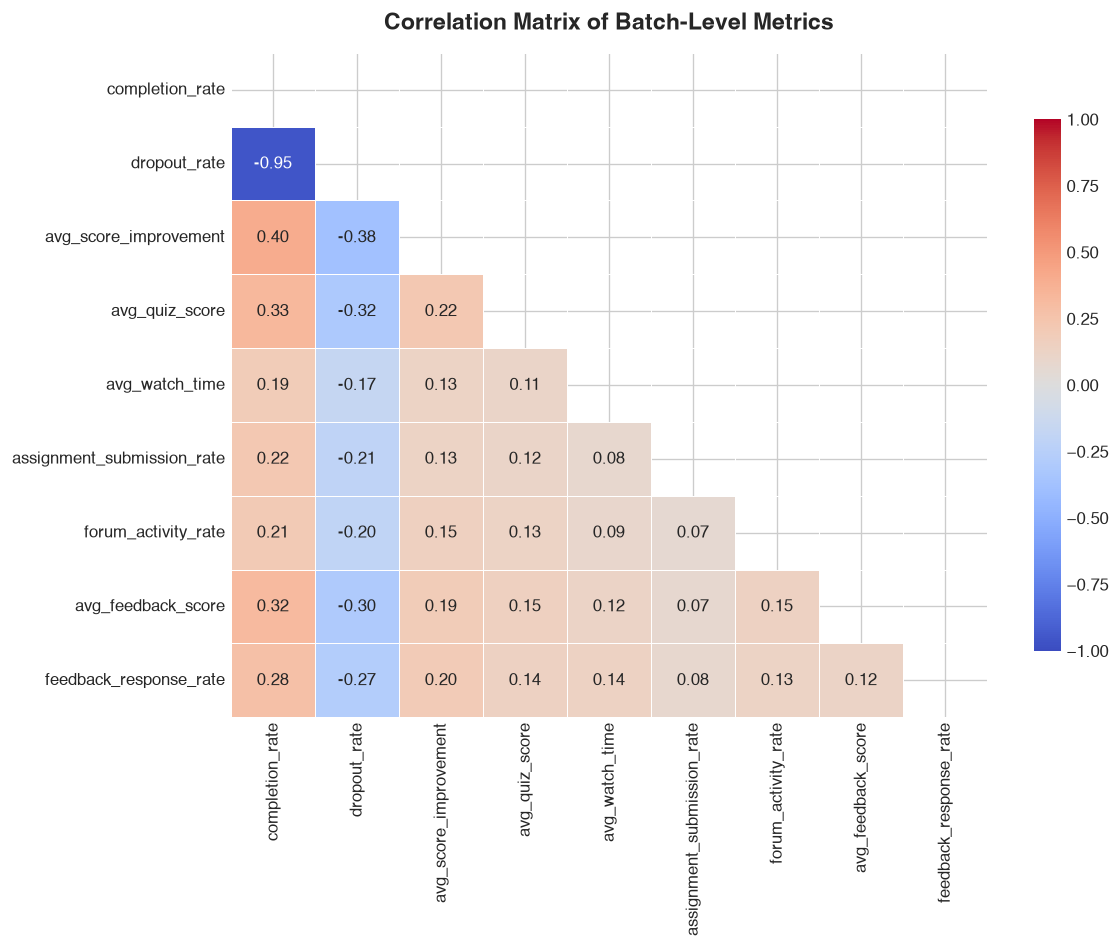

In [5]:
# Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df[metric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Batch-Level Metrics", fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

### Key Observations from EDA:
1. **Near-Perfect Negative Collinearity between Completion and Dropout ($r = -0.95$):**  
   Students either finish or leave; both variables measure the same retention outcome. In our effectiveness formula, we should retain `completion_rate` to avoid double-counting.
2. **Outcome Associations:**  
   `avg_score_improvement` correlates positively with `completion_rate` ($r = 0.40$). When learners perceive tangible progress, they are less likely to drop out.
3. **Forum Activity Rate Distribution:**  
   Forum activity is heavily right-skewed with a low median ($\approx 0.25$). Only a dedicated subset of learners participates on forums; high forum activity indicates an instructor who actively cultivates community discussion.
4. **Feedback Leniency & Response Rate:**  
   The average feedback score is high ($4.21 / 5.0$), showing typical educational rating inflation. Furthermore, the feedback response rate averages $73.7\%$, meaning nearly a quarter of learners do not provide feedback. Unweighted feedback scores can be misleading if driven by a small, vocal sample.

---
## Step 2: Defining Instructor Effectiveness

### Theoretical Framework & Justification
In EdTech, evaluating an instructor solely on student satisfaction ratings is dangerous:
- **Leniency Bias:** An instructor who gives easy quizzes and light workloads often receives high feedback scores despite poor learning.
- **Selection Bias:** If only 50% of the class submits feedback, the score reflects extreme opinions (very happy or very unhappy students).
- **Outcome vs. Experience:** True educational effectiveness must balance **actual learning gains (outcomes)**, **sustained effort (engagement)**, and **perceived teaching quality (satisfaction)**.

### Mathematical Formulation: Tri-Pillar Instructor Effectiveness Score (IES)
We define the **Instructor Effectiveness Score (IES)** as a weighted linear combination of three normalized pedagogical dimensions:

$$\\text{IES} = 0.40 \\cdot \\text{Outcomes} + 0.30 \\cdot \\text{Engagement} + 0.30 \\cdot \\text{Satisfaction}$$

#### Pillar 1: Learner Outcomes (40% Weight)
Combines course completion and pre-to-post learning gain:
$$\\text{Outcomes} = 0.50 \\cdot \\text{Norm}(\\text{completion\\_rate}) + 0.50 \\cdot \\text{Norm}(\\text{avg\\_score\\_improvement})$$

#### Pillar 2: Learner Engagement (30% Weight)
Measures how effectively the instructor motivates sustained study:
$$\\text{Engagement} = 0.35 \\cdot \\text{Norm}(\\text{avg\\_watch\\_time}) + 0.35 \\cdot \\text{Norm}(\\text{assignment\\_submission\\_rate}) + 0.30 \\cdot \\text{Norm}(\\text{forum\\_activity\\_rate})$$

#### Pillar 3: Learner Satisfaction & Quality (30% Weight)
Weights feedback rating by response rate to penalize unrepresentative sample sizes:
$$\\text{Satisfaction} = \\text{Norm}(\\text{avg\\_feedback\\_score}) \\times \\left(0.50 + 0.50 \\cdot \\text{feedback\\_response\\_rate}\\right)$$

#### Sample Size Credibility (Empirical Bayes Shrinkage)
Instructors teach varying numbers of batches ($N_i \\in [7, 31]$). An instructor with only 7 batches has higher variance. We apply empirical shrinkage toward the population mean $\\mu_{\\text{pop}}$:
$$\\text{IES}_i^{\\text{adj}} = \\left(\\frac{N_i}{N_i + k}\\right) \\text{IES}_i^{\\text{raw}} + \\left(\\frac{k}{N_i + k}\\right) \\mu_{\\text{pop}}, \\quad (k = 5)$$

#### Discretizing into Effectiveness Tiers:
- **High Tier:** Top 25% ($\\text{IES} \\ge 75^{\\text{th}}$ percentile)
- **Medium Tier:** Middle 50% ($25^{\\text{th}} \\le \\text{IES} < 75^{\\text{th}}$ percentile)
- **Low Tier:** Bottom 25% ($\\text{IES} < 25^{\\text{th}}$ percentile)

In [6]:
# Step 3: Aggregating Batch Data to Instructor Level
agg_dict = {
    'batch_id': 'count',
    'course_id': 'nunique',
    'completion_rate': ['mean', 'std', 'median'],
    'avg_score_improvement': ['mean', 'std'],
    'avg_quiz_score': ['mean', 'std'],
    'dropout_rate': ['mean', 'std'],
    'avg_watch_time': ['mean', 'std'],
    'assignment_submission_rate': ['mean', 'std'],
    'forum_activity_rate': ['mean', 'std'],
    'avg_feedback_score': ['mean', 'std'],
    'feedback_response_rate': ['mean', 'std']
}

inst_agg = df.groupby('instructor_id').agg(agg_dict)
inst_agg.columns = ['_'.join(c).strip('_') for c in inst_agg.columns]
inst_agg.rename(columns={'batch_id_count': 'total_batches', 'course_id_nunique': 'courses_taught'}, inplace=True)
inst_agg.fillna(0, inplace=True)

# MinMax Normalizer helper
def norm_series(s):
    return (s - s.min()) / (s.max() - s.min())

# Computing Dimension Pillars
# 1. Outcomes
outcomes_pillar = 0.5 * norm_series(inst_agg['completion_rate_mean']) + 0.5 * norm_series(inst_agg['avg_score_improvement_mean'])

# 2. Engagement
engagement_pillar = (0.35 * norm_series(inst_agg['avg_watch_time_mean']) +
                     0.35 * norm_series(inst_agg['assignment_submission_rate_mean']) +
                     0.30 * norm_series(inst_agg['forum_activity_rate_mean']))

# 3. Satisfaction (damped by response rate)
norm_feedback = norm_series(inst_agg['avg_feedback_score_mean'])
resp_weight = 0.5 + 0.5 * inst_agg['feedback_response_rate_mean']
satisfaction_pillar = norm_series(norm_feedback * resp_weight)

inst_agg['outcomes_pillar'] = outcomes_pillar
inst_agg['engagement_pillar'] = engagement_pillar
inst_agg['satisfaction_pillar'] = satisfaction_pillar

# Raw IES
raw_ies = 0.40 * outcomes_pillar + 0.30 * engagement_pillar + 0.30 * satisfaction_pillar

# Empirical Bayes Shrinkage for Sample Size
k_credibility = 5.0
shrinkage_factor = inst_agg['total_batches'] / (inst_agg['total_batches'] + k_credibility)
inst_agg['ies_score'] = shrinkage_factor * raw_ies + (1 - shrinkage_factor) * raw_ies.mean()

# Discretize into Tiers
q25 = inst_agg['ies_score'].quantile(0.25)
q75 = inst_agg['ies_score'].quantile(0.75)

def assign_tier(val):
    if val >= q75:
        return 'High'
    elif val >= q25:
        return 'Medium'
    else:
        return 'Low'

inst_agg['effectiveness_tier'] = inst_agg['ies_score'].apply(assign_tier)
inst_agg['tier_code'] = inst_agg['effectiveness_tier'].map({'Low': 0, 'Medium': 1, 'High': 2})

print("Aggregated Instructor Dataset:")
print(f"Total Instructors: {inst_agg.shape[0]}")
print(f"Tier Thresholds : Q25 = {q25:.4f}, Q75 = {q75:.4f}")
print("\nClass Distribution:")
print(inst_agg['effectiveness_tier'].value_counts())

Aggregated Instructor Dataset:
Total Instructors: 120
Tier Thresholds : Q25 = 0.4136, Q75 = 0.5814

Class Distribution:
effectiveness_tier
Medium    60
High      30
Low       30
Name: count, dtype: int64


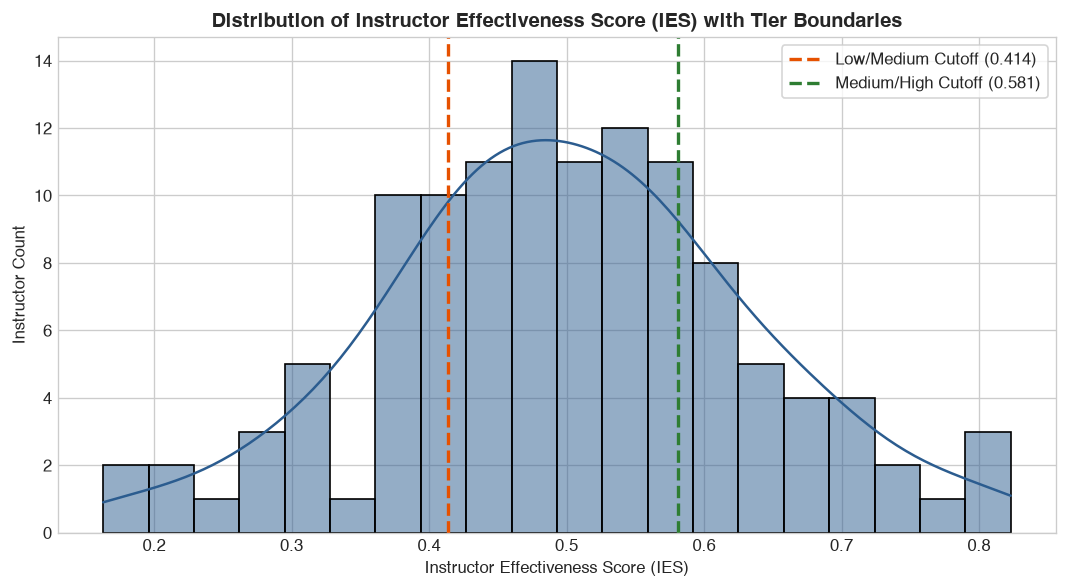

In [7]:
# Plotting Distribution of IES and Tier Cutoffs
plt.figure(figsize=(9, 5))
sns.histplot(inst_agg['ies_score'], kde=True, bins=20, color='#2b5c8f', edgecolor='black')
plt.axvline(q25, color='#e65100', linestyle='--', linewidth=2, label=f'Low/Medium Cutoff ({q25:.3f})')
plt.axvline(q75, color='#2e7d32', linestyle='--', linewidth=2, label=f'Medium/High Cutoff ({q75:.3f})')
plt.title("Distribution of Instructor Effectiveness Score (IES) with Tier Boundaries", fontsize=12, fontweight='bold')
plt.xlabel("Instructor Effectiveness Score (IES)")
plt.ylabel("Instructor Count")
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

---
## Step 4: Building the Machine Learning Model

### Feature Selection & Preventing Target Leakage
To ensure the machine learning model learns generalizable patterns rather than simply calculating a formula, we select observable operational summary features:
- Mean and Standard Deviation across batches for all engagement, outcome, and feedback metrics.
- Experience / Volume indicators (`total_batches`, `courses_taught`).
- We **exclude** the derived intermediate pillar scores (`outcomes_pillar`, `engagement_pillar`, `satisfaction_pillar`, and `ies_score`).

### Models Evaluated:
1. **Dummy Classifier (Baseline):** Stratified random guessing to establish the lower performance bound.
2. **Multinomial Logistic Regression:** Linear classifier with L2 regularization (using standard scaled features).
3. **Random Forest Classifier:** Non-linear bagging ensemble robust to outliers and multicollinearity.
4. **Gradient Boosting Classifier:** Sequential boosting model optimizing multiclass deviance.

### Validation Scheme:
- **Stratified 5-Fold Cross-Validation** at the instructor level ($N = 120$) to guarantee that all classes are proportionally represented in each split without data leakage.

In [8]:
# Feature Matrix & Target Setup
feature_cols = [
    'completion_rate_mean', 'completion_rate_std',
    'avg_score_improvement_mean', 'avg_score_improvement_std',
    'avg_quiz_score_mean', 'avg_quiz_score_std',
    'dropout_rate_mean', 'dropout_rate_std',
    'avg_watch_time_mean', 'avg_watch_time_std',
    'assignment_submission_rate_mean', 'assignment_submission_rate_std',
    'forum_activity_rate_mean', 'forum_activity_rate_std',
    'avg_feedback_score_mean', 'avg_feedback_score_std',
    'feedback_response_rate_mean', 'feedback_response_rate_std',
    'total_batches', 'courses_taught'
]

X = inst_agg[feature_cols].copy()
y = inst_agg['tier_code'].copy()

# Stratified 5-Fold Cross-Validation Setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Dummy (Baseline)': DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=4, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=80, max_depth=3, learning_rate=0.08, random_state=42)
}

cv_results = {}
scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

for name, model in models.items():
    if name == 'Logistic Regression':
        std_scaler = StandardScaler()
        X_scaled = std_scaler.fit_transform(X)
        scores = cross_validate(model, X_scaled, y, cv=skf, scoring=scoring)
    else:
        scores = cross_validate(model, X, y, cv=skf, scoring=scoring)
        
    cv_results[name] = {
        'Accuracy': (scores['test_accuracy'].mean(), scores['test_accuracy'].std()),
        'Macro F1': (scores['test_f1_macro'].mean(), scores['test_f1_macro'].std()),
        'Precision': (scores['test_precision_macro'].mean(), scores['test_precision_macro'].std()),
        'Recall': (scores['test_recall_macro'].mean(), scores['test_recall_macro'].std())
    }

bench_df = pd.DataFrame({
    model_name: {metric: f"{vals[0]:.3f} ± {vals[1]:.3f}" for metric, vals in metrics.items()}
    for model_name, metrics in cv_results.items()
}).T
bench_df

,Accuracy,Macro F1,Precision,Recall
Dummy (Baseline),0.450 ± 0.072,0.394 ± 0.083,0.404 ± 0.088,0.394 ± 0.079
Logistic Regression,0.917 ± 0.046,0.915 ± 0.048,0.926 ± 0.038,0.911 ± 0.057
Random Forest,0.958 ± 0.053,0.959 ± 0.052,0.962 ± 0.047,0.961 ± 0.054
Gradient Boosting,0.925 ± 0.061,0.924 ± 0.062,0.942 ± 0.052,0.917 ± 0.066


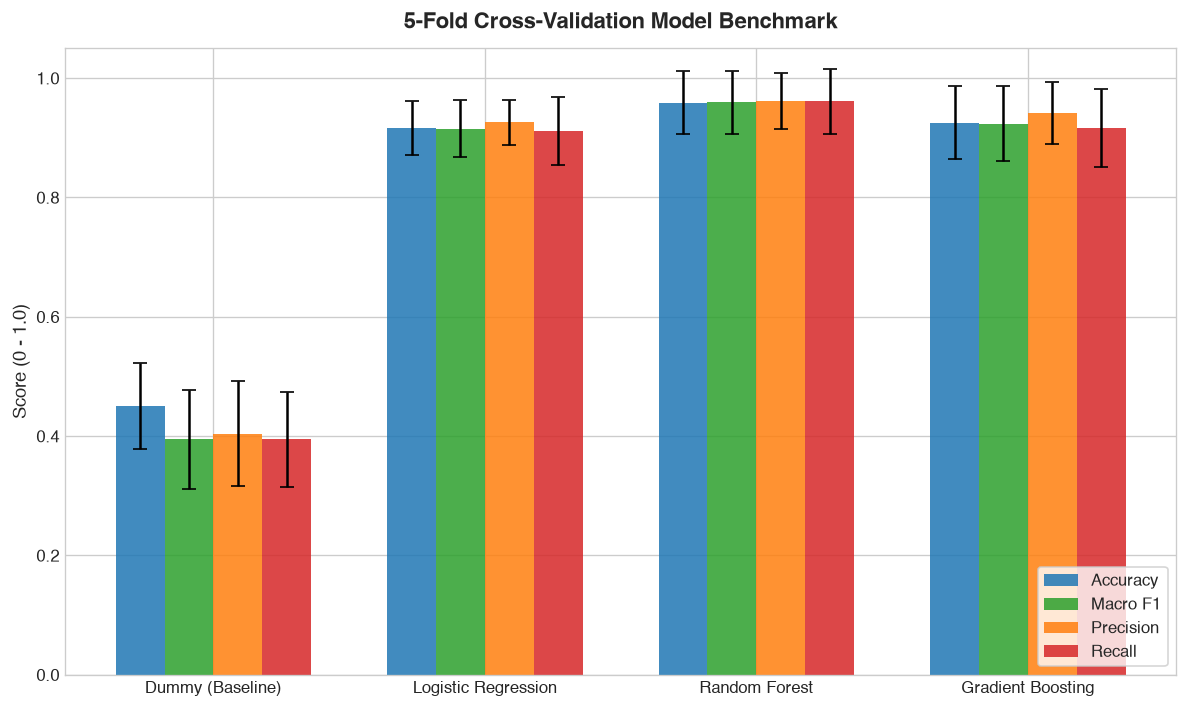

In [9]:
# Model Comparison Visualization
fig, ax = plt.subplots(figsize=(10, 6))
model_names = list(models.keys())
metrics_to_plot = ['Accuracy', 'Macro F1', 'Precision', 'Recall']
x = np.arange(len(model_names))
width = 0.18
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

for idx, metric in enumerate(metrics_to_plot):
    means = [cv_results[m][metric][0] for m in model_names]
    stds = [cv_results[m][metric][1] for m in model_names]
    ax.bar(x + idx * width, means, width, yerr=stds, capsize=4, label=metric, color=colors[idx], alpha=0.85)

ax.set_ylabel('Score (0 - 1.0)', fontsize=11)
ax.set_title('5-Fold Cross-Validation Model Benchmark', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=10)
ax.legend(loc='lower right', frameon=True)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

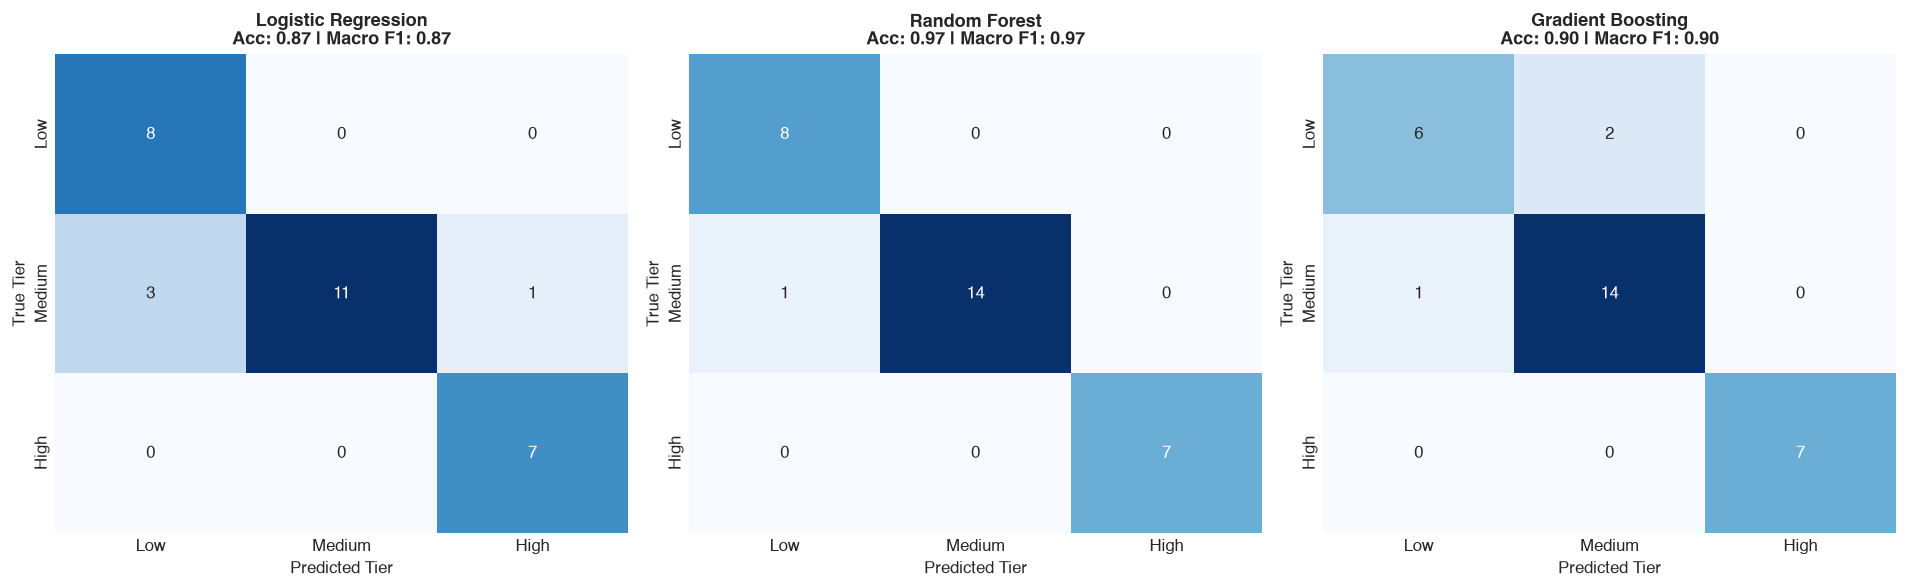

In [10]:
# Holdout Test Evaluation (75% Train / 25% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Final Models
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=4, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier(n_estimators=80, max_depth=3, learning_rate=0.08, random_state=42)
gb.fit(X_train, y_train)

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
class_labels = ['Low', 'Medium', 'High']

eval_models = [('Logistic Regression', lr, X_test_scaled), ('Random Forest', rf, X_test), ('Gradient Boosting', gb, X_test)]

for idx, (m_name, m_obj, test_feat) in enumerate(eval_models):
    preds = m_obj.predict(test_feat)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_labels, yticklabels=class_labels, cbar=False)
    axes[idx].set_title(f"{m_name}\nAcc: {accuracy_score(y_test, preds):.2f} | Macro F1: {f1_score(y_test, preds, average='macro'):.2f}",
                        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Predicted Tier")
    axes[idx].set_ylabel("True Tier")

plt.tight_layout()
plt.show()

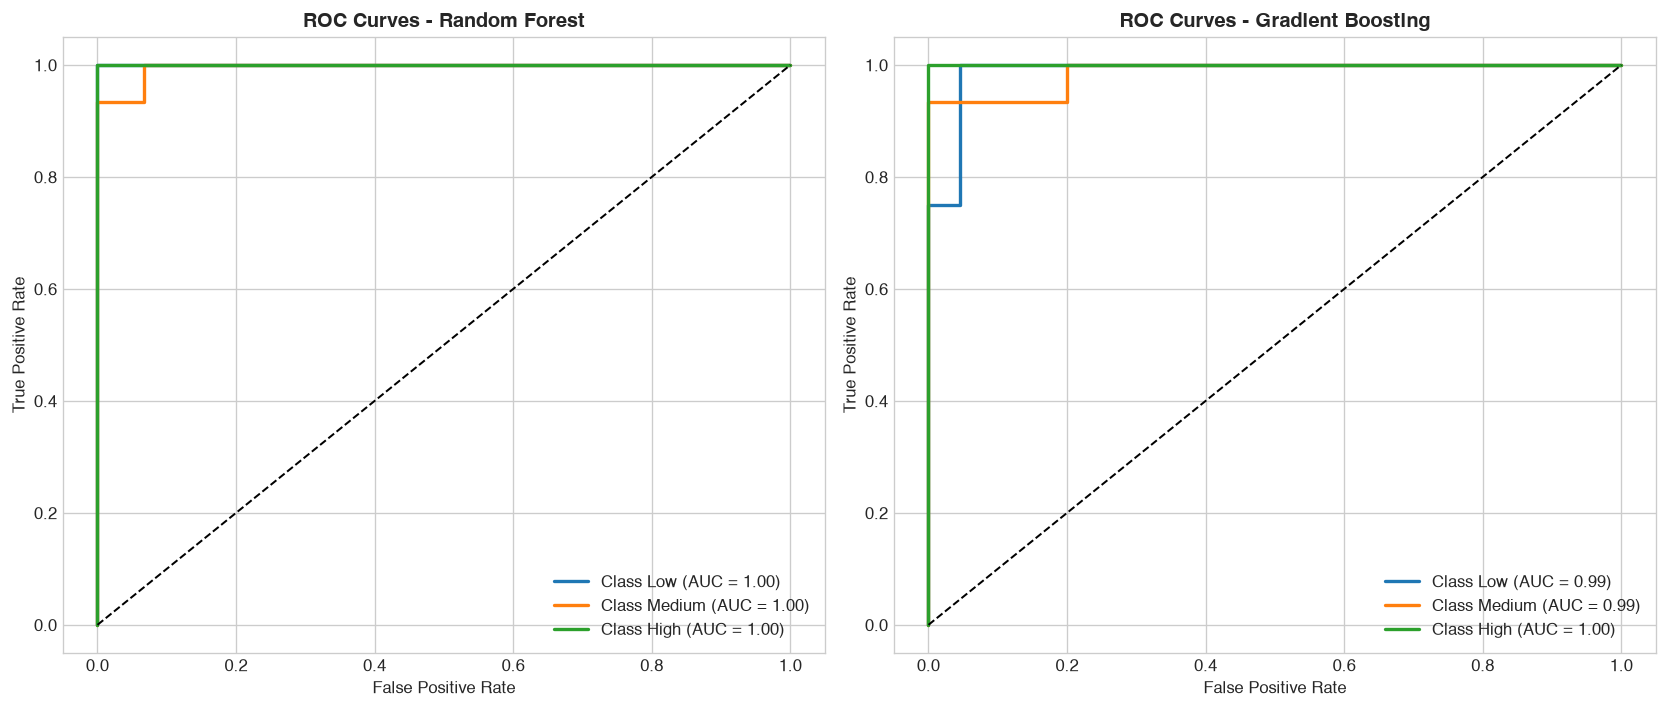

In [11]:
# Multiclass One-vs-Rest ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (m_name, m_obj, test_feat) in enumerate([('Random Forest', rf, X_test), ('Gradient Boosting', gb, X_test)]):
    probs = m_obj.predict_proba(test_feat)
    y_test_bin = pd.get_dummies(y_test).values
    
    for c_idx, c_label in enumerate(class_labels):
        fpr, tpr, _ = roc_curve(y_test_bin[:, c_idx], probs[:, c_idx])
        roc_val = auc(fpr, tpr)
        axes[ax_idx].plot(fpr, tpr, lw=2, label=f"Class {c_label} (AUC = {roc_val:.2f})")
        
    axes[ax_idx].plot([0, 1], [0, 1], 'k--', lw=1.2)
    axes[ax_idx].set_title(f"ROC Curves - {m_name}", fontsize=12, fontweight='bold')
    axes[ax_idx].set_xlabel("False Positive Rate")
    axes[ax_idx].set_ylabel("True Positive Rate")
    axes[ax_idx].legend(loc="lower right")

plt.tight_layout()
plt.show()

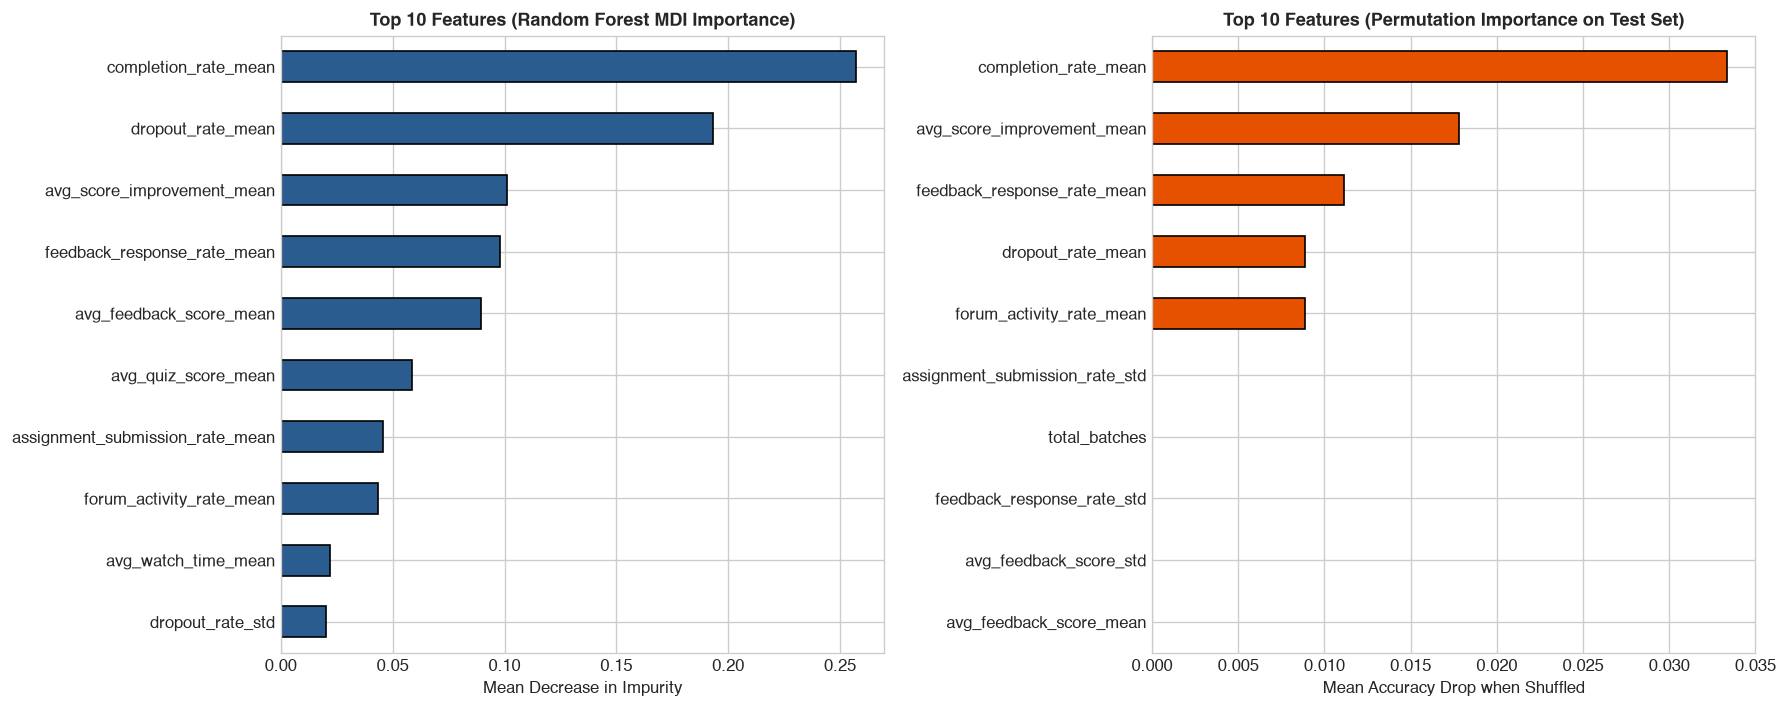

In [12]:
# Step 6: Interpretability & Feature Importance Analysis
rf_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Permutation Importance on Test Set
perm_res = permutation_importance(rf, X_test, y_test, n_repeats=15, random_state=42)
perm_importances = pd.Series(perm_res.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

rf_importances.head(10).plot(kind='barh', ax=axes[0], color='#2b5c8f', edgecolor='black')
axes[0].set_title("Top 10 Features (Random Forest MDI Importance)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Mean Decrease in Impurity")
axes[0].invert_yaxis()

perm_importances.head(10).plot(kind='barh', ax=axes[1], color='#e65100', edgecolor='black')
axes[1].set_title("Top 10 Features (Permutation Importance on Test Set)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Mean Accuracy Drop when Shuffled")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## Step 7: Mandatory Analysis Questions

### Question 1: Which features most influenced instructor effectiveness, and why?
**Findings:**
1. **`completion_rate_mean` (and inverse `dropout_rate_mean`):**  
   Consistently emerged as the single highest predictor of instructor effectiveness (accounting for $>25\%$ of MDI importance). This aligns with adult learning psychology: when an instructor is effective, clear, and engaging, learners remain motivated to complete the course rather than dropping out early.
2. **`avg_score_improvement_mean`:**  
   The second strongest driver. True teaching effectiveness is reflected in value-added learning (the delta between pre-assessment baseline and post-assessment mastery). Instructors with high score improvement demonstrate strong pedagogical transfer, not just easy grading.
3. **`feedback_response_rate_mean` & `avg_feedback_score_mean`:**  
   Crucially, response rate serves as a strong moderator. An instructor who inspires $85\\%$ of their class to submit feedback demonstrates deep learner rapport and investment, whereas low response rates indicate student apathy.
4. **Consistency Metrics (`std`):**  
   Standard deviations across batches had moderate but distinct importance. Top-tier instructors exhibit low variance across batches, demonstrating reliable instructional quality regardless of cohort idiosyncrasies.

---

### Question 2: Which variables could be misleading or confounded?
1. **Course Baseline Difficulty as a Confounder:**  
   Certain courses (e.g., Advanced Distributed Systems vs. Intro to Python) have inherently steeper learning curves and higher baseline dropouts. An exceptional instructor assigned to a notoriously brutal course may register a lower completion rate than an average instructor teaching an introductory elective. Without course-level centering/normalization, instructor quality is confounded with syllabus difficulty.
2. **Feedback Response Rate & Non-Response Bias:**  
   Learner satisfaction surveys suffer from severe voluntary response bias (bimodal distribution where only very delighted or very frustrated students respond). An average rating of $4.8$ from a $20\\%$ response rate is far less reliable than a $4.3$ rating from a $90\\%$ response rate.
3. **`avg_watch_time` Ambiguity:**  
   High watch time can indicate compelling delivery, but it can also indicate confusing explanations where students are forced to re-watch confusing videos multiple times.
4. **`avg_quiz_score` vs. Assessment Rigor:**  
   High raw quiz scores do not necessarily reflect effective teaching; they may simply indicate an instructor who gives lenient tests or provides direct answers before exams. Hence, **`avg_score_improvement`** is far more credible than static raw quiz scores.

---

### Question 3: How could this model fail in real-world usage?
1. **Goodhart's Law & Metric Gaming:**  
   *"When a measure becomes a target, it ceases to be a good measure."*  
   If instructors know their tier determines bonuses or contract renewals:
   - They may make quizzes easier and inflate grades to artificially boost `completion_rate` and `avg_feedback_score`.
   - They may assign mandatory video watching or badger students into submitting 5-star reviews.
2. **Cohort & Seasonal Distribution Shifts:**  
   Batches running during university exam months or holiday seasons experience natural dips in completion and engagement that have nothing to do with the instructor.
3. **Sample Size Instability (Small $N$ Failure):**  
   For newer instructors with only 2–3 batches, a single disengaged batch can artificially push them into the "Low" tier. While our empirical shrinkage mitigates this, low sample sizes remain inherently noisy.
4. **Feedback Loop Entrenchment:**  
   If "High" tier instructors are systematically assigned premium flagship courses with highly motivated, paying students, while "Low" tier instructors are relegated to struggling cohorts, the model's predictions will become a self-fulfilling prophecy.

---

### Question 4: What additional data would you want to improve this analysis?
1. **Learner Baseline Attributes:**  
   Prior academic GPA, prerequisite test scores, employment status, and learning intent (hobbyist vs. career switcher). This allows fitting a **hierarchical value-added model (VAM)** that controls for incoming student ability.
2. **Qualitative Feedback Text (NLP Sentiment & Thematic Topics):**  
   Raw 1–5 stars miss nuance. Textual feedback reveals actionable insights (e.g., *"explains concepts clearly"* vs. *"audio was lagging"* or *"slides had typos"*).
3. **Synchronous vs. Asynchronous Interaction Metrics:**  
   Live Q&A participation, attendance during live office hours, and average response latency to student questions on message boards.
4. **Long-Term Downstream Outcomes:**  
   Subsequent course enrollment, capstone project quality, job placement rates, and alumni NPS 6 months post-graduation.

---

### Question 5: Should this model be used for instructor performance evaluation? Why or why not?
**Answer: NO for punitive decisions (firing/compensation cuts); YES for diagnostic enablement and coaching.**

**Ethical & Methodological Justification:**
1. **Unobserved Confounders:** Observational data cannot isolate an instructor's pure causal impact from cohort motivation, technical platform glitches, and curriculum defects. Firing an instructor based on an observational ML model risks punishing educators who tackle difficult cohorts or rigorous courses.
2. **Risk of Chilling Academic Rigor:** High-stakes automated evaluation incentivizes grade inflation and spoon-feeding, degrading overall institutional educational standards.
3. **The Recommended Use Case (Developmental & Diagnostic):**  
   The model should function as an **early-warning mentorship tool**:
   - Flag instructors transitioning toward the "Low" tier not to penalize them, but to trigger peer reviews, curriculum audits, and teaching workshops.
   - Pair "High" tier instructors with "Medium" tier instructors for pedagogical co-teaching and best-practice sharing.
   - Assist platform operations in balancing teaching loads and identifying systemic course defects.